In [1]:
import pandas as pd

# データのダウンロードURL
DATA_URL = "http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"

def load_raw_data(url: str) -> pd.DataFrame:
    """
    指定されたURLからCSVデータを読み込む関数
    """
    return pd.read_csv(url)

# データの読み込み実行
df = load_raw_data(DATA_URL)

# データの基本情報の表示
print(f"Dataset Shape: {df.shape}")
print("\n--- Column Info ---")
df.info()

Dataset Shape: (64000, 12)

--- Column Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  object 
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  object 
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  object 
 8   segment          64000 non-null  object 
 9   visit            64000 non-null  int64  
 10  conversion       64000 non-null  int64  
 11  spend            64000 non-null  float64
dtypes: float64(2), int64(6), object(4)
memory usage: 5.9+ MB


In [2]:
# データの先頭5行を表示
display(df.head())

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [3]:
# 1. 特徴量エンジニアリング（前処理）
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    df_processed = df.copy()

    # 介入変数(segment)を数値化 (0: No E-Mail, 1: Mens E-Mail, 2: Womens E-Mail)
    treatment_mapping = {'No E-Mail': 0, 'Mens E-Mail': 1, 'Womens E-Mail': 2}
    df_processed['treatment'] = df_processed['segment'].map(treatment_mapping)

    # カテゴリ変数をダミー変数化（One-Hot Encoding）
    categorical_cols = ['zip_code', 'history_segment', 'channel']
    df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

    df_processed = df_processed.drop('segment', axis=1)

    return df_processed

# 前処理の実行
df_ml = preprocess_data(df)
print(f"前処理後のデータサイズ: {df_ml.shape}")

# 2. ランダム割り当ての確認（共変量のバランス確認）
covariates = ['recency', 'history', 'mens', 'womens', 'newbie']
balance_check = df_ml.groupby('treatment')[covariates].mean()

print("\n各グループの共変量の平均値（バランス確認）")
display(balance_check)

前処理後のデータサイズ: (64000, 19)

各グループの共変量の平均値（バランス確認）


,recency,history,mens,womens,newbie
treatment,,,,,
0,5.749695,240.882653,0.553224,0.547639,0.501971
1,5.773642,242.835931,0.550946,0.551415,0.501525
2,5.767850,242.536633,0.548932,0.550101,0.503250


In [4]:
print(balance_check)

            recency     history      mens    womens    newbie
treatment                                                    
0          5.749695  240.882653  0.553224  0.547639  0.501971
1          5.773642  242.835931  0.550946  0.551415  0.501525
2          5.767850  242.536633  0.548932  0.550101  0.503250


In [5]:
# 結果変数（Outcome）の指定
outcome = 'visit'

# 各グループの平均訪問率を計算
summary_visit = df_ml.groupby('treatment')[outcome].mean()

print("各グループのサイト訪問率")
print(f"0 (メールなし): {summary_visit[0]:.4f} ({summary_visit[0]*100:.1f}%)")
print(f"1 (男性向け)  : {summary_visit[1]:.4f} ({summary_visit[1]*100:.1f}%)")
print(f"2 (女性向け)  : {summary_visit[2]:.4f} ({summary_visit[2]*100:.1f}%)")

# 全体の因果効果の算出
# 介入群の訪問率 - 統制群の訪問率
ate_mens = summary_visit[1] - summary_visit[0]
ate_womens = summary_visit[2] - summary_visit[0]

print("\n全体の因果効果（ATE）")
print(f"男性向けメールの効果: +{ate_mens:.4f} (訪問率が約 {ate_mens*100:.1f} ポイント上昇)")
print(f"女性向けメールの効果: +{ate_womens:.4f} (訪問率が約 {ate_womens*100:.1f} ポイント上昇)")

各グループのサイト訪問率
0 (メールなし): 0.1062 (10.6%)
1 (男性向け)  : 0.1828 (18.3%)
2 (女性向け)  : 0.1514 (15.1%)

全体の因果効果（ATE）
男性向けメールの効果: +0.0766 (訪問率が約 7.7 ポイント上昇)
女性向けメールの効果: +0.0452 (訪問率が約 4.5 ポイント上昇)


In [6]:
# 分析対象の変数をリスト化
outcomes = ['conversion', 'spend']

for outcome in outcomes:
    # 各グループの平均値を計算
    summary = df_ml.groupby('treatment')[outcome].mean()

    print(f"【 {outcome.upper()} 】の分析")
    print("各グループの平均値")

    # conversion（確率）とspend（金額）で表示形式を分ける
    if outcome == 'conversion':
        print(f"0 (メールなし): {summary[0]:.5f} ({summary[0]*100:.2f}%)")
        print(f"1 (男性向け)  : {summary[1]:.5f} ({summary[1]*100:.2f}%)")
        print(f"2 (女性向け)  : {summary[2]:.5f} ({summary[2]*100:.2f}%)")
    else:
        print(f"0 (メールなし): ${summary[0]:.4f}")
        print(f"1 (男性向け)  : ${summary[1]:.4f}")
        print(f"2 (女性向け)  : ${summary[2]:.4f}")

    # 全体の因果効果（ATE: Average Treatment Effect）の算出
    ate_mens = summary[1] - summary[0]
    ate_womens = summary[2] - summary[0]

    print("\n全体の因果効果（ATE）")
    if outcome == 'conversion':
        print(f"男性向けメールの効果: +{ate_mens:.5f} (購入率が約 {ate_mens*100:.2f} ポイント上昇)")
        print(f"女性向けメールの効果: +{ate_womens:.5f} (購入率が約 {ate_womens*100:.2f} ポイント上昇)\n")
    else:
        print(f"男性向けメールの効果: +${ate_mens:.4f} (平均購入金額が約 ${ate_mens:.2f} 上昇)")
        print(f"女性向けメールの効果: +${ate_womens:.4f} (平均購入金額が約 ${ate_womens:.2f} 上昇)\n")

【 CONVERSION 】の分析
各グループの平均値
0 (メールなし): 0.00573 (0.57%)
1 (男性向け)  : 0.01253 (1.25%)
2 (女性向け)  : 0.00884 (0.88%)

全体の因果効果（ATE）
男性向けメールの効果: +0.00681 (購入率が約 0.68 ポイント上昇)
女性向けメールの効果: +0.00311 (購入率が約 0.31 ポイント上昇)

【 SPEND 】の分析
各グループの平均値
0 (メールなし): $0.6528
1 (男性向け)  : $1.4226
2 (女性向け)  : $1.0772

全体の因果効果（ATE）
男性向けメールの効果: +$0.7698 (平均購入金額が約 $0.77 上昇)
女性向けメールの効果: +$0.4244 (平均購入金額が約 $0.42 上昇)



In [7]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# 1. データの準備
# 結果変数（outcome）と介入変数（treatment）を特徴量から外す
outcomes = ['visit', 'conversion', 'spend']
X = df_ml.drop(columns=outcomes + ['treatment'])
y = df_ml['conversion'] # 購入（conversion）を予測ターゲットにする
treatment = df_ml['treatment']

# 2. モデルの初期化
model_0 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model_1 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model_2 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 3. グループごとの学習（Training）
# treatmentの値に応じてデータを分割し、それぞれのモデルを学習させる
model_0.fit(X[treatment == 0], y[treatment == 0])
model_1.fit(X[treatment == 1], y[treatment == 1])
model_2.fit(X[treatment == 2], y[treatment == 2])

# 4. 反実仮想の予測（Prediction）
pred_0 = model_0.predict_proba(X)[:, 1]
pred_1 = model_1.predict_proba(X)[:, 1]
pred_2 = model_2.predict_proba(X)[:, 1]

# 5. 個別因果効果の算出
# 介入した場合の予測確率 - 介入しなかった場合の予測確率
ite_mens = pred_1 - pred_0
ite_womens = pred_2 - pred_0

# 予測結果をデータフレームにまとめて確認
df_results = pd.DataFrame({
    'pred_no_email': pred_0,
    'pred_mens': pred_1,
    'pred_womens': pred_2,
    'uplift_mens': ite_mens,    # 男性向けメールによる効果
    'uplift_womens': ite_womens # 女性向けメールによる効果
})

print("\n顧客ごとの反実仮想予測と効果")
display(df_results.head())


顧客ごとの反実仮想予測と効果


,pred_no_email,pred_mens,pred_womens,uplift_mens,uplift_womens
0,0.004460,0.007331,0.004350,0.002871,-0.000110
1,0.005543,0.014356,0.006592,0.008813,0.001049
2,0.002978,0.009065,0.009773,0.006087,0.006795
3,0.005051,0.019581,0.009433,0.014530,0.004381
4,0.008214,0.014975,0.009506,0.006761,0.001292


In [8]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import pandas as pd

def train_and_predict_tlearner(X: pd.DataFrame, treatment: pd.Series, y: pd.Series, is_classifier: bool = True) -> pd.DataFrame:

    # 1. モデルの初期化 (分類か回帰かで分ける)
    if is_classifier:
        model_0 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
        model_1 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
        model_2 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    else:
        model_0 = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
        model_1 = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
        model_2 = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

    # 2. グループごとの学習
    model_0.fit(X[treatment == 0], y[treatment == 0])
    model_1.fit(X[treatment == 1], y[treatment == 1])
    model_2.fit(X[treatment == 2], y[treatment == 2])

    # 3. 全員に対する反実仮想の予測
    if is_classifier:
        pred_0 = model_0.predict_proba(X)[:, 1]
        pred_1 = model_1.predict_proba(X)[:, 1]
        pred_2 = model_2.predict_proba(X)[:, 1]
    else:
        pred_0 = model_0.predict(X)
        pred_1 = model_1.predict(X)
        pred_2 = model_2.predict(X)

    # 4. 結果のコンパイル
    df_res = pd.DataFrame({
        'pred_no_email': pred_0,
        'pred_mens': pred_1,
        'pred_womens': pred_2,
        'uplift_mens': pred_1 - pred_0,
        'uplift_womens': pred_2 - pred_0
    })

    return df_res



# VISIT（サイト訪問）のモデル実装（分類）
print("【 VISIT (サイト訪問) 】の予測")
y_visit = df_ml['visit']
df_results_visit = train_and_predict_tlearner(X, treatment, y_visit, is_classifier=True)
display(df_results_visit.head())

# SPEND（購入金額）のモデル実装（回帰）
print("\n【 SPEND (購入金額) 】の予測")
y_spend = df_ml['spend']
df_results_spend = train_and_predict_tlearner(X, treatment, y_spend, is_classifier=False)
display(df_results_spend.head())

【 VISIT (サイト訪問) 】の予測


,pred_no_email,pred_mens,pred_womens,uplift_mens,uplift_womens
0,0.090054,0.143054,0.105133,0.053000,0.015079
1,0.115392,0.223217,0.183953,0.107824,0.068561
2,0.084562,0.140988,0.151359,0.056426,0.066797
3,0.110699,0.182905,0.144518,0.072206,0.033819
4,0.137953,0.210762,0.151992,0.072809,0.014039



【 SPEND (購入金額) 】の予測


,pred_no_email,pred_mens,pred_womens,uplift_mens,uplift_womens
0,0.449376,0.544940,0.575955,0.095564,0.126579
1,0.511837,1.515507,0.639177,1.003670,0.127340
2,0.292484,1.015120,0.899168,0.722636,0.606684
3,0.276117,1.450471,1.014832,1.174354,0.738715
4,1.190740,2.535440,1.885674,1.344700,0.694934


In [9]:
print(df_results_visit.head())
print(df_results_spend.head())

   pred_no_email  pred_mens  pred_womens  uplift_mens  uplift_womens
0       0.090054   0.143054     0.105133     0.053000       0.015079
1       0.115392   0.223217     0.183953     0.107824       0.068561
2       0.084562   0.140988     0.151359     0.056426       0.066797
3       0.110699   0.182905     0.144518     0.072206       0.033819
4       0.137953   0.210762     0.151992     0.072809       0.014039
   pred_no_email  pred_mens  pred_womens  uplift_mens  uplift_womens
0       0.449376   0.544940     0.575955     0.095564       0.126579
1       0.511837   1.515507     0.639177     1.003670       0.127340
2       0.292484   1.015120     0.899168     0.722636       0.606684
3       0.276117   1.450471     1.014832     1.174354       0.738715
4       1.190740   2.535440     1.885674     1.344700       0.694934


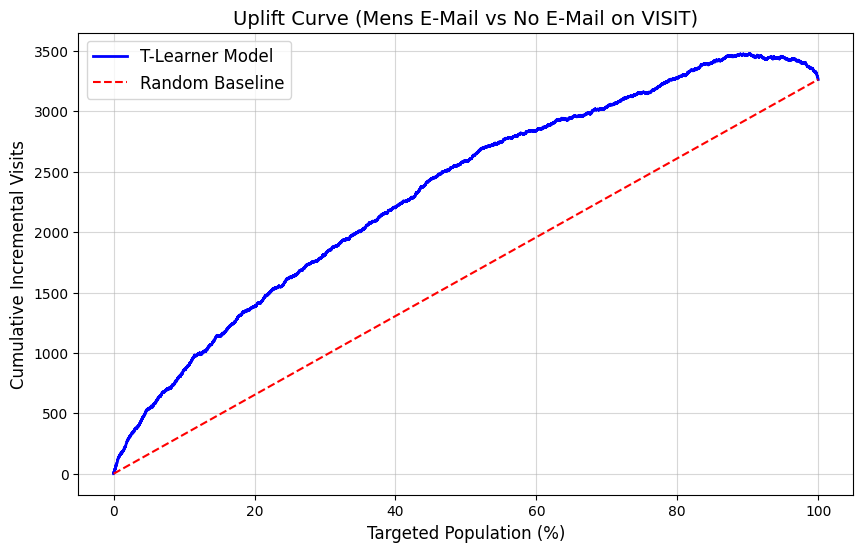

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def plot_uplift_curve(y_true, treatment, uplift_scores, treatment_group=1, control_group=0):

    # 評価に必要なデータをまとめる
    df_eval = pd.DataFrame({
        'y': y_true,
        'treatment': treatment,
        'score': uplift_scores
    })

    # 評価対象の2グループ（例：メールなし vs 男性向け）のみに絞る
    df_eval = df_eval[df_eval['treatment'].isin([treatment_group, control_group])].copy()

    # 予測スコアが高い順（降順）に並び替える
    df_eval = df_eval.sort_values(by='score', ascending=False).reset_index(drop=True)

    # 各時点での介入群・対照群の累積人数を計算
    df_eval['n_treatment'] = (df_eval['treatment'] == treatment_group).cumsum()
    df_eval['n_control'] = (df_eval['treatment'] == control_group).cumsum()

    # 各時点での介入群・対照群の累積成果を計算
    df_eval['y_treatment'] = (df_eval['y'] * (df_eval['treatment'] == treatment_group)).cumsum()
    df_eval['y_control'] = (df_eval['y'] * (df_eval['treatment'] == control_group)).cumsum()

    # 累積アップリフト（増加した純粋な成果数）を計算
    # (介入群の平均成果 - 対照群の平均成果) * 全体人数
    df_eval['cumulative_uplift'] = (
        (df_eval['y_treatment'] / df_eval['n_treatment'].replace(0, np.nan)) -
        (df_eval['y_control'] / df_eval['n_control'].replace(0, np.nan))
    ) * (df_eval['n_treatment'] + df_eval['n_control'])

    df_eval['cumulative_uplift'] = df_eval['cumulative_uplift'].fillna(0)

    # グラフの描画
    plt.figure(figsize=(10, 6))

    # 実績のカーブ
    plt.plot(df_eval.index / len(df_eval) * 100, df_eval['cumulative_uplift'],
             label='T-Learner Model', color='blue', linewidth=2)

    # ランダムに送った場合のベースライン
    plt.plot([0, 100], [0, df_eval['cumulative_uplift'].iloc[-1]],
             label='Random Baseline', color='red', linestyle='--')

    plt.xlabel('Targeted Population (%)', fontsize=12)
    plt.ylabel('Cumulative Incremental Visits', fontsize=12)
    plt.title('Uplift Curve (Mens E-Mail vs No E-Mail on VISIT)', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.5)
    plt.show()

plot_uplift_curve(
    y_true=df_ml['visit'],
    treatment=df_ml['treatment'],
    uplift_scores=df_results_visit['uplift_mens'],
    treatment_group=1, # 男性向けメール
    control_group=0    # メールなし
)

【購入率 (Conversion)】に対する男性向けメールの効果


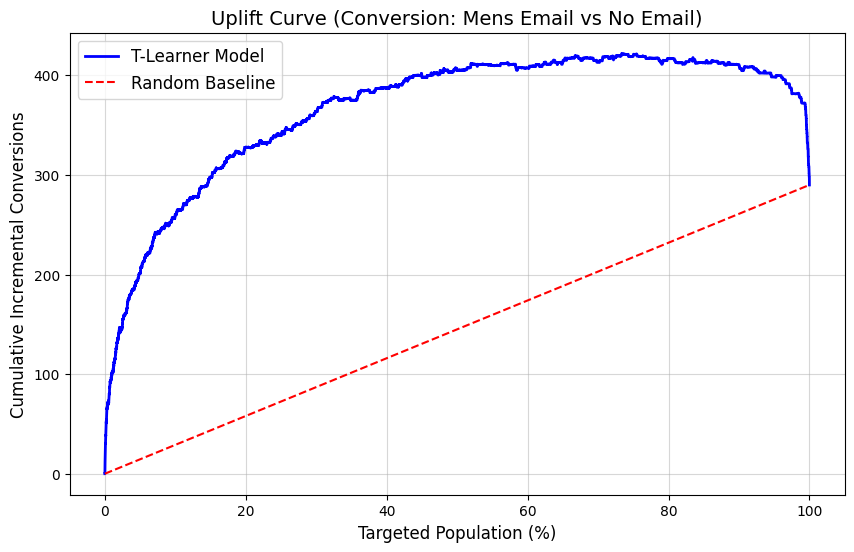


【購入金額 (Spend)】に対する男性向けメールの効果


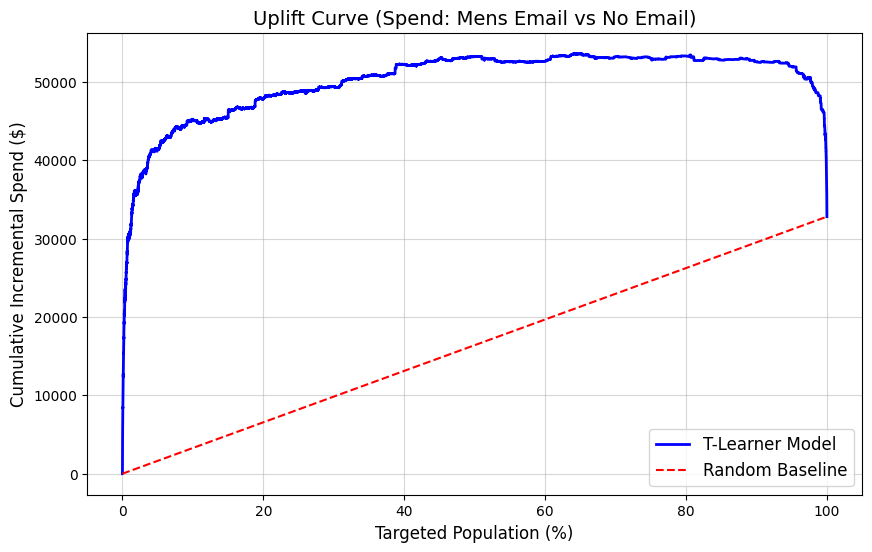

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_uplift_curve_readable(y_true, treatment, uplift_scores, treatment_group=1, control_group=0, title="Uplift Curve", ylabel="Cumulative Incremental Outcome"):

    # 1. 必要なデータだけを集めたデータフレームを作成
    df = pd.DataFrame({
        'y': y_true,
        'treatment': treatment,
        'score': uplift_scores
    })

    # 2. 評価したい2つのグループ（例：男性向け vs メールなし）だけに絞り込む
    df = df[df['treatment'].isin([treatment_group, control_group])].copy()

    # 3. 予測スコアが高い順（効果が高い順）に並び替える
    df = df.sort_values(by='score', ascending=False).reset_index(drop=True)

    # 4. グループごとに「人数」を上から数える
    df['is_treatment'] = (df['treatment'] == treatment_group)
    df['is_control'] = (df['treatment'] == control_group)
    df['count_treatment'] = df['is_treatment'].cumsum()
    df['count_control'] = df['is_control'].cumsum()

    # 5. グループごとに「成果（購入や金額）」を上から足す
    # 該当グループなら成果の数値を、違うグループなら0を入れる列を作る
    df['outcome_treatment'] = 0.0
    df.loc[df['treatment'] == treatment_group, 'outcome_treatment'] = df['y']

    df['outcome_control'] = 0.0
    df.loc[df['treatment'] == control_group, 'outcome_control'] = df['y']

    # cumsum() で上から足し算して、累積成果を出す
    df['cumsum_outcome_treatment'] = df['outcome_treatment'].cumsum()
    df['cumsum_outcome_control'] = df['outcome_control'].cumsum()

    # 6. アップリフト（純増した成果）の計算
    # (介入群の平均成果 - 統制群の平均成果) * ここまで見た合計人数
    average_outcome_treatment = df['cumsum_outcome_treatment'] / df['count_treatment'].replace(0, np.nan)
    average_outcome_control = df['cumsum_outcome_control'] / df['count_control'].replace(0, np.nan)
    total_people_so_far = df['count_treatment'] + df['count_control']

    df['cumulative_uplift'] = (average_outcome_treatment - average_outcome_control) * total_people_so_far
    df['cumulative_uplift'] = df['cumulative_uplift'].fillna(0)

    # 7. グラフの描画
    plt.figure(figsize=(10, 6))
    x_axis = df.index / len(df) * 100 # 横軸：アプローチした割合(%)

    # モデルの曲線
    plt.plot(x_axis, df['cumulative_uplift'], label='T-Learner Model', color='blue', linewidth=2)

    # ランダムベースライン
    baseline_end = df['cumulative_uplift'].iloc[-1]
    plt.plot([0, 100], [0, baseline_end], label='Random Baseline', color='red', linestyle='--')

    plt.xlabel('Targeted Population (%)', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.5)
    plt.show()

# 実際のデータを使ってグラフを描画する実行ブロック

# 1. 購入（Conversion）の評価
print("【購入率 (Conversion)】に対する男性向けメールの効果")
plot_uplift_curve_readable(
    y_true=df_ml['conversion'],
    treatment=df_ml['treatment'],
    uplift_scores=df_results['uplift_mens'],
    treatment_group=1,
    control_group=0,
    title="Uplift Curve (Conversion: Mens Email vs No Email)",
    ylabel="Cumulative Incremental Conversions"
)

# 2. 購入金額（Spend）の評価
print("\n【購入金額 (Spend)】に対する男性向けメールの効果")
plot_uplift_curve_readable(
    y_true=df_ml['spend'],
    treatment=df_ml['treatment'],
    uplift_scores=df_results_spend['uplift_mens'], # df_results_spend は先ほど作ったSpendの予測結果
    treatment_group=1,
    control_group=0,
    title="Uplift Curve (Spend: Mens Email vs No Email)",
    ylabel="Cumulative Incremental Spend ($)"
)

【購入率 (Conversion)】に対する女性向けメールの効果


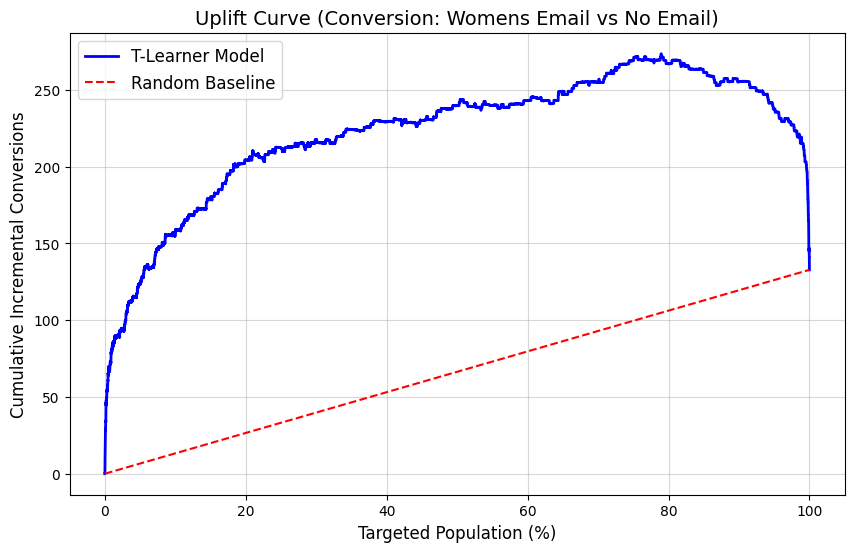


【購入金額 (Spend)】に対する女性向けメールの効果


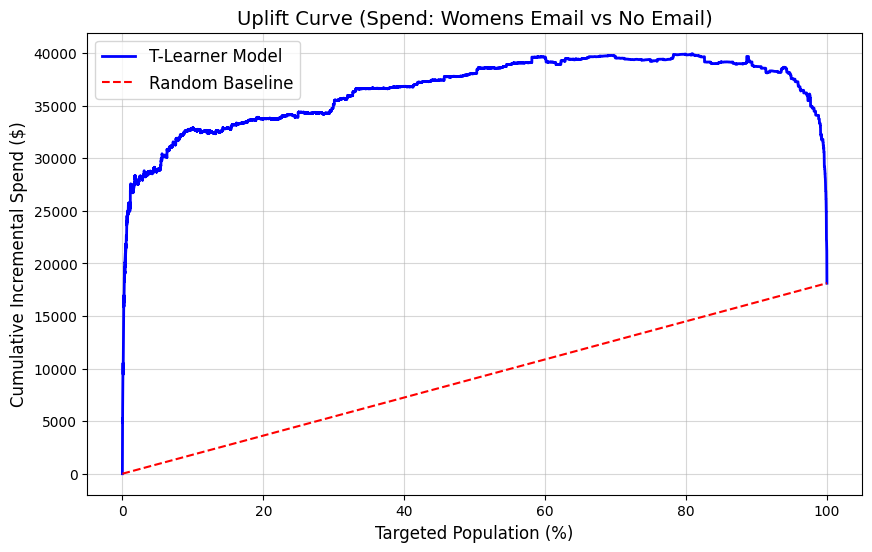


【サイト訪問 (Visit)】に対する女性向けメールの効果


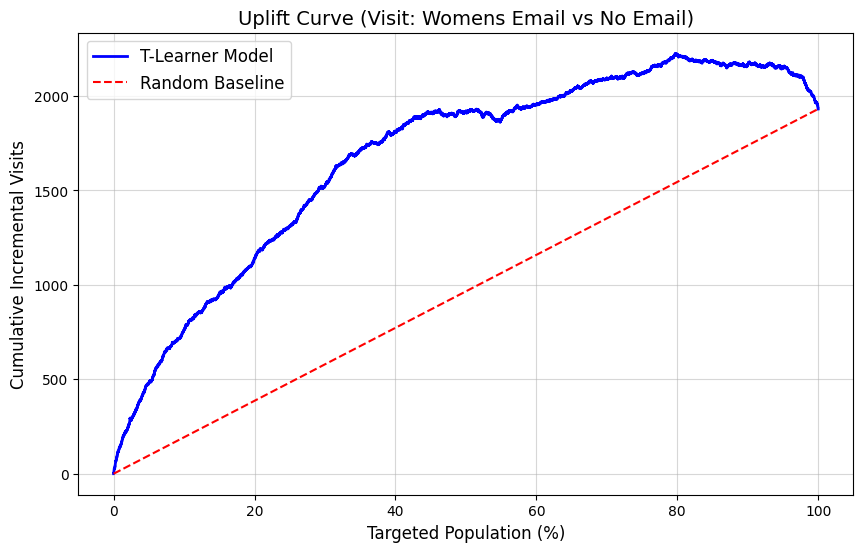

In [12]:
# 【女性向けメール】のアップリフトカーブ描画

# 1. 購入（Conversion）の評価
print("【購入率 (Conversion)】に対する女性向けメールの効果")
plot_uplift_curve_readable(
    y_true=df_ml['conversion'],
    treatment=df_ml['treatment'],
    uplift_scores=df_results['uplift_womens'], # 女性向けのスコア（uplift_womens）を指定
    treatment_group=2,                         # グループ2（女性向けメール）を指定
    control_group=0,
    title="Uplift Curve (Conversion: Womens Email vs No Email)",
    ylabel="Cumulative Incremental Conversions"
)

# 2. 購入金額（Spend）の評価
print("\n【購入金額 (Spend)】に対する女性向けメールの効果")
plot_uplift_curve_readable(
    y_true=df_ml['spend'],
    treatment=df_ml['treatment'],
    uplift_scores=df_results_spend['uplift_womens'], # 女性向けのスコア（uplift_womens）を指定
    treatment_group=2,                               # グループ2（女性向けメール）を指定
    control_group=0,
    title="Uplift Curve (Spend: Womens Email vs No Email)",
    ylabel="Cumulative Incremental Spend ($)"
)

# 3. サイト訪問（Visit）の評価
print("\n【サイト訪問 (Visit)】に対する女性向けメールの効果")
plot_uplift_curve_readable(
    y_true=df_ml['visit'],
    treatment=df_ml['treatment'],
    uplift_scores=df_results_visit['uplift_womens'], # 先ほど作成したvisitの予測結果を使用
    treatment_group=2,                               # グループ2（女性向けメール）を指定
    control_group=0,
    title="Uplift Curve (Visit: Womens Email vs No Email)",
    ylabel="Cumulative Incremental Visits"
)

In [13]:
import pandas as pd
import numpy as np

def simulate_profit(df_ml, uplift_scores, treatment_group=1, control_group=0, cost_per_email=0.10):
    """
    全員送信 vs AIターゲティングの利益をシミュレーションする関数
    """
    # 1. 必要なデータをまとめる
    df = pd.DataFrame({
        'spend': df_ml['spend'],       # 実際の購入金額
        'treatment': df_ml['treatment'], # 実際のグループ
        'score': uplift_scores         # 予測スコア（購入金額のアップリフト）
    })

    # 評価対象のグループ（男性向け vs メールなし）だけに絞り込む
    df = df[df['treatment'].isin([treatment_group, control_group])].copy()

    # 【シナリオ1】従来の手法：全員に一斉送信する場合
    # 純増売上 ＝ (介入群の平均売上 - 統制群の平均売上) × 全体人数
    avg_spend_treatment_all = df[df['treatment'] == treatment_group]['spend'].mean()
    avg_spend_control_all = df[df['treatment'] == control_group]['spend'].mean()

    incremental_revenue_all = (avg_spend_treatment_all - avg_spend_control_all) * len(df)
    total_cost_all = len(df) * cost_per_email
    profit_all = incremental_revenue_all - total_cost_all

    # 【シナリオ2】モデル導入：スコアがプラス（>0）の人だけに送信する場合
    df_target = df[df['score'] > 0]

    # ターゲット層の中での純増売上を計算
    avg_spend_treatment_target = df_target[df_target['treatment'] == treatment_group]['spend'].mean()
    avg_spend_control_target = df_target[df_target['treatment'] == control_group]['spend'].mean()

    incremental_revenue_target = (avg_spend_treatment_target - avg_spend_control_target) * len(df_target)
    total_cost_target = len(df_target) * cost_per_email
    profit_target = incremental_revenue_target - total_cost_target

    print(f"利益シミュレーション（メール1通コスト: ${cost_per_email}）")
    print(f"シナリオ1：全員に一斉送信（従来手法）")
    print(f"  送信対象者数: {len(df):,}人")
    print(f"  純増売上:     ${incremental_revenue_all:,.2f}")
    print(f"  送信コスト:   ${total_cost_all:,.2f}")
    print(f"  最終利益:     ${profit_all:,.2f}")

    print(f"\nシナリオ2：予測（スコア>0）のみに送信")
    print(f"  送信対象者数: {len(df_target):,}人 (全体の {len(df_target)/len(df)*100:.1f}%)")
    print(f"  純増売上:     ${incremental_revenue_target:,.2f}")
    print(f"  送信コスト:   ${total_cost_target:,.2f}")
    print(f"  最終利益:     ${profit_target:,.2f}")

    print(f"利益改善額: + ${(profit_target - profit_all):,.2f}")

# 実行ブロック
simulate_profit(
    df_ml=df_ml,
    uplift_scores=df_results_spend['uplift_mens'], # Spendの予測スコア
    treatment_group=1,                             # 男性向けメール
    control_group=0,                               # メールなし
    cost_per_email=0.10                            # コスト仮定 (1通10セント)
)

利益シミュレーション（メール1通コスト: $0.1）
シナリオ1：全員に一斉送信（従来手法）
  送信対象者数: 42,613人
  純増売上:     $32,804.64
  送信コスト:   $4,261.30
  最終利益:     $28,543.34

シナリオ2：予測（スコア>0）のみに送信
  送信対象者数: 39,628人 (全体の 93.0%)
  純増売上:     $52,618.59
  送信コスト:   $3,962.80
  最終利益:     $48,655.79
利益改善額: + $20,112.45


In [14]:
# 【女性向けメール】の利益シミュレーション

print("【女性向けメール】の利益シミュレーション")
simulate_profit(
    df_ml=df_ml,
    uplift_scores=df_results_spend['uplift_womens'], # 女性向けメールのSpendスコア
    treatment_group=2,                               # グループ2（女性向けメール）
    control_group=0,                                 # メールなし
    cost_per_email=0.10                              # コスト仮定 (1通10セント)
)

【女性向けメール】の利益シミュレーション
利益シミュレーション（メール1通コスト: $0.1）
シナリオ1：全員に一斉送信（従来手法）
  送信対象者数: 42,693人
  純増売上:     $18,119.43
  送信コスト:   $4,269.30
  最終利益:     $13,850.13

シナリオ2：予測（スコア>0）のみに送信
  送信対象者数: 32,729人 (全体の 76.7%)
  純増売上:     $39,422.14
  送信コスト:   $3,272.90
  最終利益:     $36,149.24
利益改善額: + $22,299.11


In [15]:
import pandas as pd

# 1. 元のデータに女性向けメールのスコアを結合
df_profile = df_ml.copy()
df_profile['uplift_score'] = df_results_spend['uplift_womens']

# 2. スコアがプラス（Target）か、ゼロ以下（Non-Target）かでラベル付け
df_profile['target_segment'] = df_profile['uplift_score'].apply(
    lambda x: '1. Target (Score > 0)' if x > 0 else '2. Non-Target (Score <= 0)'
)

# 3. 比較したい顧客属性（特徴量）のリスト
# recency: 最終購入からの経過月数（小さいほど最近買った）
# history: 過去の累積購入金額
# mens / womens: 過去に男性用/女性用商品を買ったか (1:Yes, 0:No)
# newbie: 新規顧客か (1:Yes, 0:No)
features = ['recency', 'history', 'mens', 'womens', 'newbie']

# 4. グループごとに属性の平均値を計算
profile_summary = df_profile.groupby('target_segment')[features].mean().T

# 見やすくするために「差分」を追加
profile_summary['Difference'] = profile_summary['1. Target (Score > 0)'] - profile_summary['2. Non-Target (Score <= 0)']

# 5. 結果の出力
print("【女性向けメール】 ターゲット層 vs 非ターゲット層の顧客プロファイル（平均値）\n")
print(profile_summary.round(2))

【女性向けメール】 ターゲット層 vs 非ターゲット層の顧客プロファイル（平均値）

target_segment  1. Target (Score > 0)  2. Non-Target (Score <= 0)  Difference
recency                          5.95                        5.15        0.81
history                        233.14                      271.39      -38.25
mens                             0.51                        0.69       -0.18
womens                           0.57                        0.47        0.10
newbie                           0.63                        0.08        0.55


In [16]:
import pandas as pd

# 1. 元のデータに男性向けメールのスコアを結合
df_profile_mens = df_ml.copy()
# ここを df_results_spend['uplift_mens'] に変更
df_profile_mens['uplift_score'] = df_results_spend['uplift_mens']

# 2. スコアがプラス（Target）か、ゼロ以下（Non-Target）かでラベル付け
df_profile_mens['target_segment'] = df_profile_mens['uplift_score'].apply(
    lambda x: '1. Target (Score > 0)' if x > 0 else '2. Non-Target (Score <= 0)'
)

# 3. 比較したい顧客属性（特徴量）のリスト
features = ['recency', 'history', 'mens', 'womens', 'newbie']

# 4. グループごとに属性の平均値を計算
profile_summary_mens = df_profile_mens.groupby('target_segment')[features].mean().T

# 見やすくするために「差分」を追加
profile_summary_mens['Difference'] = profile_summary_mens['1. Target (Score > 0)'] - profile_summary_mens['2. Non-Target (Score <= 0)']

# 5. 結果の出力
print("【男性向けメール】 ターゲット層 vs 非ターゲット層の顧客プロファイル（平均値）\n")
print(profile_summary_mens.round(2))

【男性向けメール】 ターゲット層 vs 非ターゲット層の顧客プロファイル（平均値）

target_segment  1. Target (Score > 0)  2. Non-Target (Score <= 0)  Difference
recency                          5.63                        7.58       -1.95
history                        247.97                      164.63       83.34
mens                             0.55                        0.50        0.05
womens                           0.55                        0.56       -0.01
newbie                           0.53                        0.08        0.45


In [17]:
from sklearn.ensemble import RandomForestRegressor

# S-Learner の実装

# 1. データの準備（男性向けメール=1 と コントロール群=0 に絞る）
df_s = df_ml[df_ml['treatment'].isin([0, 1])].copy()

X_features_s = ['recency', 'history', 'mens', 'womens', 'newbie', 'treatment']
X_s = df_s[X_features_s]
y_s = df_s['spend']

# 2. モデルの学習
model_s = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model_s.fit(X_s, y_s)

# 3. アップリフトスコアの算出

# 全員にメールを送った場合
X_s_treated = X_s.copy()
X_s_treated['treatment'] = 1
pred_treated = model_s.predict(X_s_treated) # メールあり世界の予測購入金額

# 全員にメールを送らなかった場合
X_s_control = X_s.copy()
X_s_control['treatment'] = 0
pred_control = model_s.predict(X_s_control) # メールなし世界の予測購入金額

# スコア = (メールありの予測値) - (メールなしの予測値)
df_s['uplift_score_s_learner'] = pred_treated - pred_control

# 4. 結果の確認
print("S-Learnerが算出したアップリフトスコア（最初の5人）")
print(df_s[['spend', 'treatment', 'uplift_score_s_learner']].head())

S-Learnerが算出したアップリフトスコア（最初の5人）
    spend  treatment  uplift_score_s_learner
1     0.0          0                0.796478
3     0.0          1                1.106016
8     0.0          1                1.134075
13    0.0          1                0.327684
14    0.0          0                0.595633


【S-Learner】 アップリフトカーブ (Spend: Mens Email vs No Email)


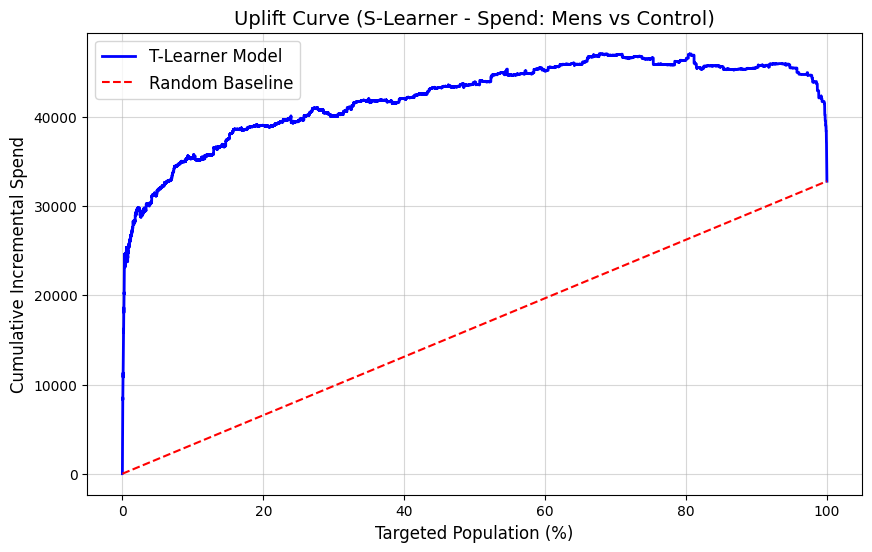

In [18]:
# 5. S-Learnerの評価（アップリフトカーブの描画）
print("【S-Learner】 アップリフトカーブ (Spend: Mens Email vs No Email)")
plot_uplift_curve_readable(
    y_true=df_s['spend'],
    treatment=df_s['treatment'],
    uplift_scores=df_s['uplift_score_s_learner'], # ここにS-Learnerのスコアを指定
    treatment_group=1,
    control_group=0,
    title="Uplift Curve (S-Learner - Spend: Mens vs Control)",
    ylabel="Cumulative Incremental Spend"
)

In [20]:
import numpy as np
import pandas as pd

def calculate_auuc(y_true, treatment, uplift_scores, treatment_group=1, control_group=0):
    """
    アップリフトカーブの下の面積(AUUC)を計算する関数
    """
    # データをスコアの降順（高い順）に並べ替える
    df = pd.DataFrame({'y': y_true, 't': treatment, 'score': uplift_scores})
    df = df[df['t'].isin([treatment_group, control_group])]
    df = df.sort_values(by='score', ascending=False).reset_index(drop=True)

    # 累積の件数と成果を計算
    df['t_cumsum'] = (df['t'] == treatment_group).cumsum()
    df['c_cumsum'] = (df['t'] == control_group).cumsum()
    df['t_y_cumsum'] = (df['y'] * (df['t'] == treatment_group)).cumsum()
    df['c_y_cumsum'] = (df['y'] * (df['t'] == control_group)).cumsum()

    # 各時点での平均成果を計算
    df['t_mean'] = (df['t_y_cumsum'] / df['t_cumsum'].replace(0, np.nan)).fillna(0)
    df['c_mean'] = (df['c_y_cumsum'] / df['c_cumsum'].replace(0, np.nan)).fillna(0)

    # 累積人数（横軸）
    df['n'] = np.arange(1, len(df) + 1)

    # アップリフトカーブの値（縦軸）
    df['uplift_curve'] = (df['t_mean'] - df['c_mean']) * df['n']

    # numpyのtrapz（台形公式）を使って面積を計算
    auuc = np.trapz(df['uplift_curve'].fillna(0), df['n'])

    return auuc

# 定量評価（AUUC）によるモデル比較

# 1. T-LearnerのAUUCを計算
auuc_t_learner = calculate_auuc(
    y_true=df_ml['spend'],
    treatment=df_ml['treatment'],
    uplift_scores=df_results_spend['uplift_mens'], # T-Learnerのスコア
    treatment_group=1,
    control_group=0
)

# 2. S-LearnerのAUUCを計算
auuc_s_learner = calculate_auuc(
    y_true=df_s['spend'],
    treatment=df_s['treatment'],
    uplift_scores=df_s['uplift_score_s_learner'],  # S-Learnerのスコア
    treatment_group=1,
    control_group=0
)

# 3. ランダムベースラインのAUUCを計算（スコアをランダムな値にして計算）
np.random.seed(42)
random_scores = np.random.rand(len(df_s))
auuc_random = calculate_auuc(
    y_true=df_s['spend'],
    treatment=df_s['treatment'],
    uplift_scores=random_scores,
    treatment_group=1,
    control_group=0
)

# 結果の出力
print("モデルの定量評価 (AUUC: Area Under the Uplift Curve)")
print(f"1. T-Learner AUUC : {auuc_t_learner:,.0f}")
print(f"2. S-Learner AUUC : {auuc_s_learner:,.0f}")
print(f"3. Random Baseline: {auuc_random:,.0f}")

モデルの定量評価 (AUUC: Area Under the Uplift Curve)
1. T-Learner AUUC : 2,131,879,738
2. S-Learner AUUC : 1,791,914,151
3. Random Baseline: 590,221,764


/tmp/ipykernel_24159/2126955217.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auuc = np.trapz(df['uplift_curve'].fillna(0), df['n'])
/tmp/ipykernel_24159/2126955217.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auuc = np.trapz(df['uplift_curve'].fillna(0), df['n'])
/tmp/ipykernel_24159/2126955217.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auuc = np.trapz(df['uplift_curve'].fillna(0), df['n'])


In [21]:
from sklearn.ensemble import RandomForestRegressor

# データの準備
df_x = df_ml[df_ml['treatment'].isin([0, 1])].copy()
X_features = ['recency', 'history', 'mens', 'womens', 'newbie']

df_1 = df_x[df_x['treatment'] == 1] # メールあり群
df_0 = df_x[df_x['treatment'] == 0] # メールなし群

# 【Step 1】ベースモデルの学習（T-Learnerと同じ）
model_1 = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model_0 = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model_1.fit(df_1[X_features], df_1['spend'])
model_0.fit(df_0[X_features], df_0['spend'])

# 【Step 2】仮想の因果効果（D）の算出
# メールあり群: 現実の購入額 - もしメールなしだったらの予測額
D_1 = df_1['spend'] - model_0.predict(df_1[X_features])
# メールなし群: もしメールありだったらの予測額 - 現実の購入額
D_0 = model_1.predict(df_0[X_features]) - df_0['spend']

# 【Step 3】「因果効果」を直接予測するモデルの学習
model_x1 = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model_x0 = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model_x1.fit(df_1[X_features], D_1)
model_x0.fit(df_0[X_features], D_0)

# 【Step 4】スコアの統合
# 全員に対して、2つのモデルから効果を予測
pred_effect_x1 = model_x1.predict(df_x[X_features])
pred_effect_x0 = model_x0.predict(df_x[X_features])

# A/Bテスト(RCT)で半々に分かれているため、0.5ずつで単純平均
df_x['uplift_score_x_learner'] = (pred_effect_x1 * 0.5) + (pred_effect_x0 * 0.5)

# AUUCによる定量評価
auuc_x_learner = calculate_auuc(
    y_true=df_x['spend'],
    treatment=df_x['treatment'],
    uplift_scores=df_x['uplift_score_x_learner'],
    treatment_group=1,
    control_group=0
)

print("AUUC 最終スコアボード")
print(f"1. T-Learner : 2,131,879,738")
print(f"2. S-Learner : 1,791,914,151")
print(f"3. X-Learner : {auuc_x_learner:,.0f}")
print(f"4. Random    :   590,221,764")

AUUC 最終スコアボード
1. T-Learner : 2,131,879,738
2. S-Learner : 1,791,914,151
3. X-Learner : 2,001,649,215
4. Random    :   590,221,764


/tmp/ipykernel_24159/2126955217.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auuc = np.trapz(df['uplift_curve'].fillna(0), df['n'])
